```
<12_war.ipynb>

제미나이 의존도: 10-20%

이번에는 전쟁에 쓰이는 무기라는 주제로 객체 탐지를 해보았다.
역시나 csv 파일이 있었기 때문에 해보았다.
csv를 뜯어보니 image_id에 '%20'이라는 문자가 들어있었는데, 공백을 대체하는 문자인거 같다.

csv는 이제 충분히 해봤으니 json을 해볼 차례인거 같다.
```

In [51]:
import os
import pandas as pd
from PIL import Image
import random
import shutil
from ultralytics import YOLO
import time
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

In [24]:
src_image_path = 'dataset/war/war_TCHBYGON/obshaya_papk'
src_csv_path = 'dataset/war/war_TCHBYGON/war_tech_gont-export.csv'

src_image_set = set(os.listdir(src_image_path))

df = pd.read_csv(src_csv_path)

# image 컬럼에 'artilleriya%20(1).jpg'이라고 되어있지만 실제 이미지명은 'artilleriya (1).jpg'임.
# 그래서 %20을 ' '(공백)으로 replace했다.
df['image'] = df['image'].str.replace('%20', ' ', regex=False)

# print(df.head())

classes = sorted(df['label'].unique())
class_map = {name: idx for idx, name in enumerate(classes)}

save_txt_path = 'dataset/war/war_TCHBYGON/labels'
os.makedirs(save_txt_path, exist_ok=True)

count = 0

for image_id, group in df.groupby('image'):
    pure_name, ext = os.path.splitext(image_id)
    if image_id in src_image_set:
        full_src_image_path = os.path.join(src_image_path, image_id)
        with Image.open(full_src_image_path) as img:
            img_width, img_height = img.size

        txt_lines = []
        for idx, row in group.iterrows():
            class_name = row['label']
            xmin = row['xmin']
            ymin = row['ymin']
            xmax = row['xmax']
            ymax = row['ymax']

            class_id = class_map[class_name]
            x_center = (xmin + xmax) / (2 * img_width)
            y_center = (ymin + ymax) / (2 * img_height)
            obj_width = (xmax - xmin) / img_width
            obj_height = (ymax - ymin) / img_height

            line = f"{class_id} {x_center:.6f} {y_center:.6f} {obj_width:.6f} {obj_height:.6f}"
            txt_lines.append(line)

        full_save_txt_path = os.path.join(save_txt_path, f'{pure_name}.txt')
        with open(full_save_txt_path, 'w', encoding='utf-8') as f:
            if len(txt_lines) > 0:
                f.write('\n'.join(txt_lines) + '\n')
            else:
                # f.write('')
                print(f"배경 이미지: {image_id}")

        count += 1

print(f'Finished {count}')

Finished 2546


In [43]:
set_txt_path = set(os.listdir(save_txt_path))
src_image_list = [f for f in os.listdir(src_image_path) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]

src_image_path = 'dataset/war/war_TCHBYGON/obshaya_papk'

random.seed(42)
random.shuffle(src_image_list)

# train valid test 8:1:1
train_split_idx = int(len(src_image_list) * 0.8)
val_test_split_idx = int(len(src_image_list) * 0.1)

train_images = src_image_list[:train_split_idx]
val_images = src_image_list[train_split_idx:train_split_idx + val_test_split_idx]
test_images = src_image_list[train_split_idx + val_test_split_idx:]

split_data = {'train': train_images, 'valid': val_images, 'test': test_images}

for split_type, images in split_data.items():
    count = 0
    dest_image_path = f'dataset/war/{split_type}/images'
    dest_label_path = f'dataset/war/{split_type}/labels'
    os.makedirs(dest_image_path, exist_ok=True)
    os.makedirs(dest_label_path, exist_ok=True)
    
    for image in images:
        pure_name, ext = os.path.splitext(image)
        txt_name = f"{pure_name}.txt"
        if txt_name in set_txt_path:
            full_src_image_path = os.path.join(src_image_path, image)
            full_dest_image_path = os.path.join(dest_image_path, image)
            shutil.copy(full_src_image_path, full_dest_image_path)
            
            full_src_label_path = os.path.join(save_txt_path, txt_name)
            full_dest_label_path = os.path.join(dest_label_path, txt_name)
            shutil.copy(full_src_label_path, full_dest_label_path)

            count += 1
    print(f"{split_type} count: {count}")

train count: 2036
valid count: 254
test count: 256


In [45]:
yaml_path = 'dataset/war/data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write('train: ../train/images\n')
    f.write('val: ../valid/images\n')
    f.write('test: ../test/images\n')
    f.write('\n')
    f.write(f'nc: {len(class_map)}\n')
    f.write(f'names: {list(class_map.keys())}')

In [49]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

start_time = time.time()

model.train(
    data='dataset/war/data.yaml', 
    epochs=15, 
    imgsz=640, 
    device='mps', 
    project=os.path.join(current_dir, 'runs'), 
    name='war'
)

elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f'{mins}:{secs}')

New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/war/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=war, nbs=64, nms=False,

In [54]:
def inspect_detection(image_path, conf_threshold=0.45, iou_threshold=0.5):
    model = YOLO('runs/war/weights/best.pt')

    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device='mps'
    )

    result = preds[0]

    annotated_img_bgr = result.plot()
    img_rgb = cv2.cvtColor(annotated_img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Conf: {conf_threshold} | IoU: {iou_threshold}", fontsize=12)
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/war/test/images/artilleriya (102).jpg: 448x640 1 artilleriya, 11.2ms
Speed: 1.5ms preprocess, 11.2ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)


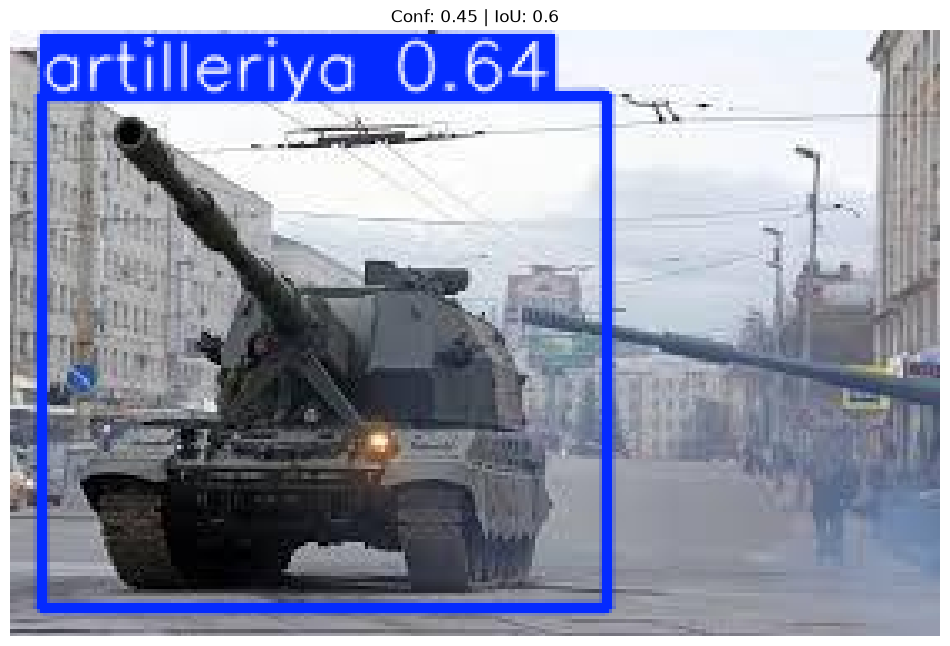

In [62]:
image_path = 'dataset/war/test/images/artilleriya (102).jpg'
inspect_detection(image_path, conf_threshold=0.45, iou_threshold=0.6)